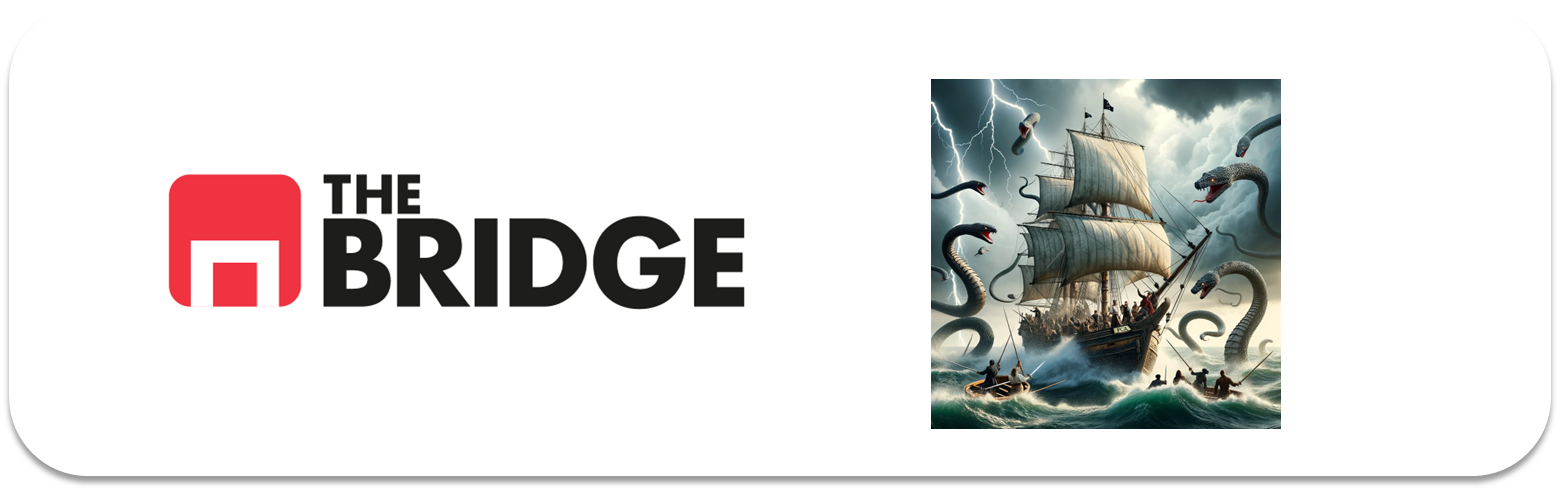

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, recall_score

import warnings
warnings.filterwarnings("ignore")

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [2]:
# 1. Cargamos el dataset de caras Olivetti (400 imagenes de 64x64 = 4096 pixeles/features)
olivetti = fetch_olivetti_faces()

print("images (sin aplanar):", olivetti.images.shape)
print("data (aplanado):", olivetti.data.shape)
print("target:", olivetti.target.shape, "| personas distintas:", len(np.unique(olivetti.target)))

images (sin aplanar): (400, 64, 64)
data (aplanado): (400, 4096)
target: (400,) | personas distintas: 40


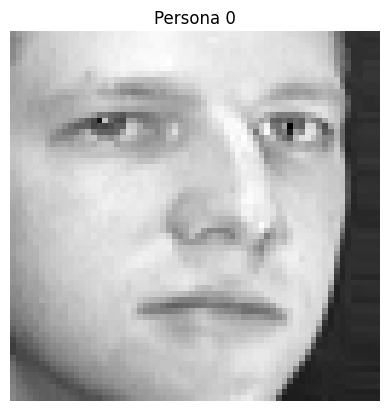

In [3]:
# Una cara de muestra
plt.imshow(olivetti.data[4].reshape(64, 64), cmap="gray")
plt.axis("off")
plt.title(f"Persona {olivetti.target[4]}")
plt.show()

In [4]:
# Construimos el dataframe: cada pixel es una feature
df = pd.DataFrame(olivetti.data, columns=[f"pixel_{i}" for i in range(olivetti.data.shape[1])])
df["face_id"] = olivetti.target

target = "face_id"
print("Shape:", df.shape)
df.head()

Shape: (400, 4097)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_4087,pixel_4088,pixel_4089,pixel_4090,pixel_4091,pixel_4092,pixel_4093,pixel_4094,pixel_4095,face_id
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0


*Ojo: el target viene **ordenado** (10 fotos seguidas de cada persona). Lo barajamos antes de partir.*

In [5]:
df_back = df.copy()
df = df_back.sample(len(df_back), random_state=42).reset_index(drop=True)
df["face_id"].head(10)

0    20
1    28
2     3
3    21
4     9
5     8
6    32
7     9
8    26
9    12
Name: face_id, dtype: int64

**2. Split train/test** con 80 instancias en test y estratificado por el target
(2 fotos de cada una de las 40 personas). **Este split se mantiene en toda la practica.**

In [6]:
train_set, test_set = train_test_split(df, test_size=80, stratify=df[target], random_state=42)

X_train = train_set.drop(target, axis=1)
y_train = train_set[target]
X_test = test_set.drop(target, axis=1)
y_test = test_set[target]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Fotos por persona en test:", y_test.value_counts().unique())

X_train: (320, 4096) | X_test: (80, 4096)
Fotos por persona en test: [2]


**3. ¿MiniEDA?**

Lo hacemos **muy rapido**, y ademas hay que justificar por que casi no tiene sentido aqui:

1. **Por relevancia de cada feature:** cada feature es UN pixel. Analizar pixel a pixel para entenderlo no
   tiene ningun sentido semantico (¿que significa "pixel_2035"?). Como mucho podemos entrenar un RandomForest
   y pintar sus `feature_importances_` para ver si hay pixeles muy dominantes.
2. **Por escalado:** los pixeles ya vienen entre 0 y 1 y todos en la misma escala, no hay que escalar.

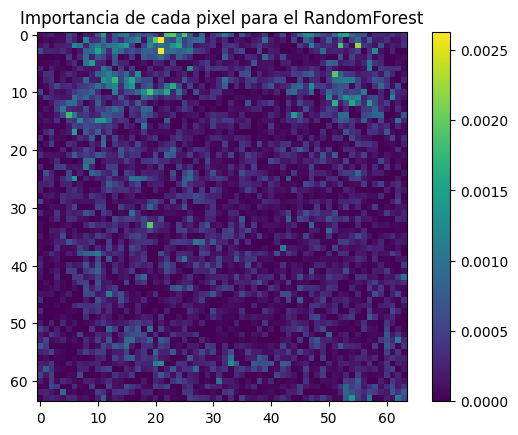

count    4096.000000
mean        0.000244
std         0.000283
min         0.000000
25%         0.000032
50%         0.000168
75%         0.000349
max         0.002628
dtype: float64


In [7]:
# Aprovechamos y entrenamos ya el modelo BASELINE (RandomForest sobre las 4096 features)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

# Pintamos la importancia de cada pixel "como si fuera una cara"
imagen_importancia = rf_baseline.feature_importances_.reshape(64, 64)
plt.imshow(imagen_importancia)
plt.colorbar()
plt.title("Importancia de cada pixel para el RandomForest")
plt.show()

print(pd.Series(rf_baseline.feature_importances_).describe())

*Se intuye algo (ojos/nariz destacan un pelin), pero **todas las importancias son minusculas y muy parecidas**
(max ~0.0026): no hay forma de hacer seleccion de features con criterio aqui. Esta es justo la gracia de la PCA:
en lugar de tirar pixeles, **cada componente principal se lleva un poquito de todos los pixeles**.*

count    4096.000000
mean        0.693583
std         0.097013
min         0.396694
25%         0.640496
50%         0.706612
75%         0.756198
max         0.938017
Name: rango, dtype: float64


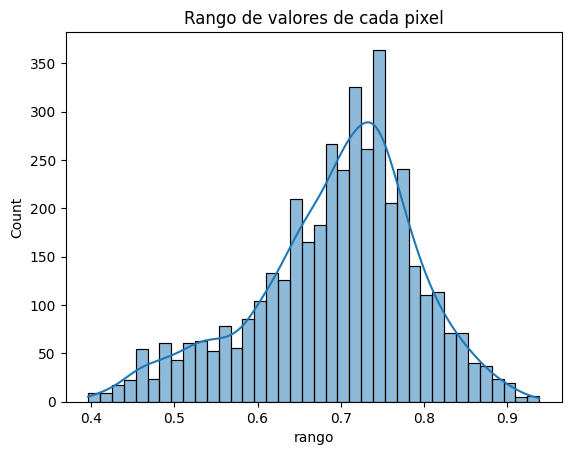

In [8]:
# Comprobamos lo del escalado: rango (max - min) de cada pixel
df_describe = X_train.describe().T
df_describe["rango"] = df_describe["max"] - df_describe["min"]
print(df_describe["rango"].describe())
sns.histplot(df_describe["rango"], kde=True)
plt.title("Rango de valores de cada pixel")
plt.show()

*Todos los pixeles se mueven en rangos muy similares y ya estan entre 0 y 1 -> **no hay que escalar**.*

**4. Metricas baseline**

La metrica es **`balanced_accuracy`** (= recall medio / macro). ¿Por que? Porque es un problema **multiclase
con 40 clases perfectamente balanceadas** y **todas las personas nos importan igual**: no queremos que el modelo
acierte mucho con unas y falle con otras. Ademas, en el negocio (detectar personas non-gratas) el coste de
**no detectar** a alguien es alto -> nos interesa el **recall**.

In [9]:
# Scoring contra TEST
y_pred = rf_baseline.predict(X_test)
print(classification_report(y_test, y_pred))

baseline_test = recall_score(y_test, y_pred, average="macro")
print("BASELINE test (balanced accuracy):", round(baseline_test, 4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          17       0.67    

In [10]:
# Scoring en CROSS VALIDATION (5 folds)
baseline_cv = np.mean(cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring="balanced_accuracy"))
baseline_cv = round(baseline_cv, 3)

print("BASELINE cv  (balanced accuracy):", baseline_cv)
print("BASELINE test(balanced accuracy):", round(baseline_test, 3))

BASELINE cv  (balanced accuracy): 0.933
BASELINE test(balanced accuracy): 0.95


*Guardamos los dos como **baseline** para el resto de la practica.*

*Nota: hemos sacado mejor resultado en test que en CV. Eso "congratula" pero hay que ser prudente: el test son
solo 80 imagenes. **El numero realista es el de la validacion cruzada**, que es mas pesimista. Nos quedaremos
siempre con el peor de los dos para decidir.*

### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

*Aqui el modelo va **dentro de la microcamara** y trabaja con la imagen **ya comprimida**: comprime con PCA
y clasifica directamente sobre las componentes principales (nunca descomprime).*

In [11]:
# 1. PCA sin especificar nada
pca = PCA()
pca.fit(X_train)

print("Numero de componentes que ha sacado:", pca.n_components_)

Numero de componentes que ha sacado: 320


*¿Solo 320 componentes y no 4096? Es lo esperado: cuando **`n_features` > `n_instancias`** (4096 > 320),
el maximo numero de componentes principales que se pueden obtener es el numero de instancias. Nos vale de
sobra, porque con esas 320 ya explicamos el 100% de la varianza.*

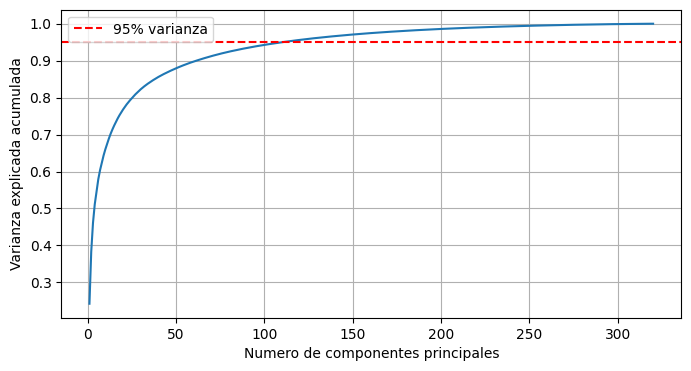

Con 2 PCs explicamos: 38.27 %
Con 55 PCs explicamos: 88.91 %


In [12]:
varianza_acumulada = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada)
plt.axhline(y=0.95, color="r", linestyle="--", label="95% varianza")
plt.xlabel("Numero de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.legend()
plt.grid()
plt.show()

print("Con 2 PCs explicamos:", round(varianza_acumulada[1] * 100, 2), "%")
print("Con 55 PCs explicamos:", round(varianza_acumulada[54] * 100, 2), "%")

**2. Rango de componentes para una compresion del 0.2% al 2.5%**

Ojo a la definicion del enunciado: compresion del 1% = el dataset se queda **en el 1% de su tamaño original**. Es decir:

$$\text{compresion (\%)} = \frac{n\_componentes}{n\_features} \times 100 \;\;\Rightarrow\;\; n\_componentes = \frac{\text{compresion} \times n\_features}{100}$$

In [13]:
compresion_maxima = 0.2
compresion_minima = 2.5

num_features = len(X_train.columns)     # 4096
num_pcs = []

for rango in np.linspace(compresion_maxima, compresion_minima, 5):
    num_pc = int(rango * num_features / 100)
    print(f"Para {rango:0.3f}% de compresion -> {num_pc} PCs")
    num_pcs.append(num_pc)

print("\nValores a probar:", num_pcs)

Para 0.200% de compresion -> 8 PCs
Para 0.775% de compresion -> 31 PCs
Para 1.350% de compresion -> 55 PCs
Para 1.925% de compresion -> 78 PCs
Para 2.500% de compresion -> 102 PCs

Valores a probar: [8, 31, 55, 78, 102]


In [14]:
# Proyectamos train y test con la MISMA PCA (fit solo en train, nunca refiteamos en test)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("X_train_pca:", X_train_pca.shape, "| X_test_pca:", X_test_pca.shape)

X_train_pca: (320, 320) | X_test_pca: (80, 320)


*Truco: como las componentes salen **ordenadas de mayor a menor varianza explicada**, quedarse con las
`n` primeras columnas de `X_train_pca` es exactamente lo mismo que hacer `PCA(n)`. Asi no repetimos el fit.*

In [15]:
# 3. Entrenamos un modelo por cada numero de componentes
lista_valores = []

for num_pc in num_pcs:
    X_train_temp = X_train_pca[:, :num_pc]
    X_test_temp = X_test_pca[:, :num_pc]

    rf_clf = RandomForestClassifier(random_state=42)
    eval_cv = np.mean(cross_val_score(rf_clf, X_train_temp, y_train, cv=5, scoring="balanced_accuracy"))

    rf_clf.fit(X_train_temp, y_train)
    eval_test = recall_score(y_test, rf_clf.predict(X_test_temp), average="macro")

    lista_valores.append({
        "num_pc": num_pc,
        "compresion_%": round(num_pc / num_features * 100, 3),
        "eval_cv": round(eval_cv * 100, 2),
        "baseline_cv": round(baseline_cv * 100, 2),
        "diff_cv": round((baseline_cv - eval_cv) * 100, 2),
        "eval_test": round(eval_test * 100, 2),
        "baseline_test": round(baseline_test * 100, 2),
        "diff_test": round((baseline_test - eval_test) * 100, 2),
    })
    print(f"{num_pc:3d} PCs -> CV {eval_cv*100:.2f} | test {eval_test*100:.2f}")

  8 PCs -> CV 78.75 | test 83.75


 31 PCs -> CV 90.25 | test 91.25


 55 PCs -> CV 91.50 | test 95.00


 78 PCs -> CV 89.75 | test 95.00


102 PCs -> CV 90.25 | test 96.25


In [16]:
# 4. El dataframe con todo lo que pide el enunciado
df_resultados = pd.DataFrame(lista_valores)
df_resultados

,num_pc,compresion_%,eval_cv,baseline_cv,diff_cv,eval_test,baseline_test,diff_test
0,8,0.195,78.75,93.3,14.55,83.75,95.0,11.25
1,31,0.757,90.25,93.3,3.05,91.25,95.0,3.75
2,55,1.343,91.50,93.3,1.80,95.00,95.0,0.00
3,78,1.904,89.75,93.3,3.55,95.00,95.0,0.00
4,102,2.490,90.25,93.3,3.05,96.25,95.0,-1.25


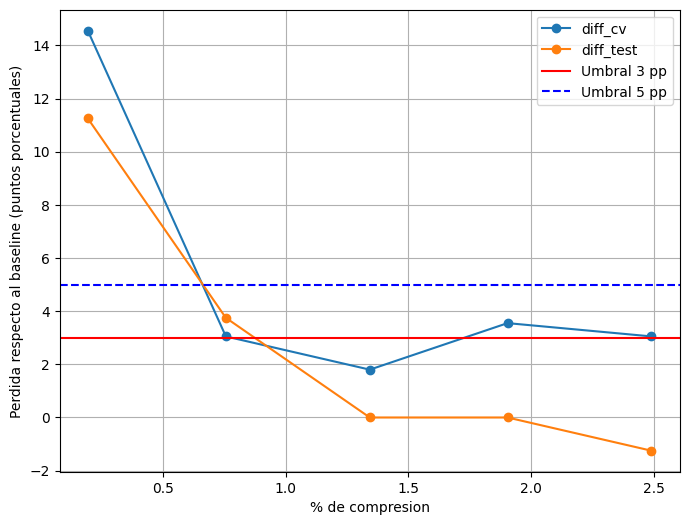

In [17]:
plt.figure(figsize=(8, 6))
umbral_1 = 3
umbral_2 = 5

for linea in ["diff_cv", "diff_test"]:
    plt.plot(df_resultados["compresion_%"], df_resultados[linea], "o-", label=linea)

plt.axhline(y=umbral_1, color="r", linestyle="-", label=f"Umbral {umbral_1} pp")
plt.axhline(y=umbral_2, color="b", linestyle="--", label=f"Umbral {umbral_2} pp")
plt.xlabel("% de compresion")
plt.ylabel("Perdida respecto al baseline (puntos porcentuales)")
plt.legend()
plt.grid()
plt.show()

In [18]:
# 5. Buscamos la MAYOR compresion (menos PCs) con perdida < 3 pp en CV Y en test
# (el enunciado dice "tanto en CV como en test" -> es un AND, no un OR)
cumple = (df_resultados["diff_cv"] < umbral_1) & (df_resultados["diff_test"] < umbral_1)

if df_resultados[cumple].empty:
    print(f"Nadie cumple con {umbral_1} pp, probamos con {umbral_2} pp")
    cumple = (df_resultados["diff_cv"] < umbral_2) & (df_resultados["diff_test"] < umbral_2)

candidatos = df_resultados[cumple]
display(candidatos)

# De los que cumplen, el de MAYOR compresion es el que menos PCs usa
elegido = candidatos.loc[candidatos["num_pc"].idxmin()]
num_pc_microcamara = int(elegido["num_pc"])

print(f"\nELEGIDO: {num_pc_microcamara} PCs -> compresion al {elegido['compresion_%']}% "
      f"del tamaño original (perdida: {elegido['diff_cv']} pp en CV y {elegido['diff_test']} pp en test)")

,num_pc,compresion_%,eval_cv,baseline_cv,diff_cv,eval_test,baseline_test,diff_test
2,55,1.343,91.5,93.3,1.8,95.0,95.0,0.0



ELEGIDO: 55 PCs -> compresion al 1.343% del tamaño original (perdida: 1.8 pp en CV y 0.0 pp en test)


**Conclusion Parte #2:** con **55 componentes principales** la microcamara puede trabajar con imagenes
reducidas al **1.34% de su tamaño original** (unas 75 veces menos datos) perdiendo solo **1.8 pp en CV** y
**0 pp en test**. Practicamente clasifica igual de bien que con los 4096 pixeles.

Fijate en dos detalles:

* Con **8 PCs (0.2% de compresion)** el modelo se hunde: perdemos **14.55 pp en CV**. Comprimir tiene un
  limite, no todo vale.
* A partir de 55 PCs, **seguir añadiendo componentes no mejora** (78 y 102 PCs dan CV parecido o peor) pero
  ocupa mas. Por eso 55 es el punto dulce: la mayor compresion que cumple el umbral de 3 pp en CV **y** en test.

### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

*Ahora el escenario es otro: la microcamara **solo comprime y envia**; el modelo esta en el **servidor
central**, que **descomprime** (`inverse_transform`) y clasifica sobre la imagen reconstruida de 4096 pixeles.
Como el ancho de banda es minimo, buscamos comprimir aun mas: entre el **1 por mil y el 1 por ciento**.*

In [19]:
# 1. Rango de PCs entre 0.1% y 1% de compresion
compresion_maxima = 0.1
compresion_minima = 1

num_pcs_3 = []
for rango in np.linspace(compresion_maxima, compresion_minima, 5):
    num_pc = int(rango * num_features / 100)
    print(f"Para {rango:0.3f}% de compresion -> {num_pc} PCs")
    num_pcs_3.append(num_pc)

print("\nValores a probar:", num_pcs_3)

Para 0.100% de compresion -> 4 PCs
Para 0.325% de compresion -> 13 PCs
Para 0.550% de compresion -> 22 PCs
Para 0.775% de compresion -> 31 PCs
Para 1.000% de compresion -> 40 PCs

Valores a probar: [4, 13, 22, 31, 40]


In [20]:
# 2. Para cada valor: comprimimos, DESCOMPRIMIMOS y entrenamos sobre lo descomprimido
lista_valores_3 = []

for num_pc in num_pcs_3:
    pca_temp = PCA(num_pc)
    X = pca_temp.fit_transform(X_train)          # comprimimos (320 x num_pc)
    X_t = pca_temp.transform(X_test)

    # AQUI ESTA LA CLAVE: descomprimimos -> volvemos a 4096 features (pero con perdida)
    X_train_unzipped = pca_temp.inverse_transform(X)
    X_test_unzipped = pca_temp.inverse_transform(X_t)

    rf_clf = RandomForestClassifier(random_state=42)
    eval_cv = np.mean(cross_val_score(rf_clf, X_train_unzipped, y_train, cv=5, scoring="balanced_accuracy"))

    rf_clf.fit(X_train_unzipped, y_train)
    eval_test = recall_score(y_test, rf_clf.predict(X_test_unzipped), average="macro")

    lista_valores_3.append({
        "num_pc": num_pc,
        "compresion_%": round(num_pc / num_features * 100, 2),
        "eval_cv": round(eval_cv * 100, 2),
        "baseline_cv": round(baseline_cv * 100, 2),
        "diff_cv": round((baseline_cv - eval_cv) * 100, 2),
        "eval_test": round(eval_test * 100, 2),
        "baseline_test": round(baseline_test * 100, 2),
        "diff_test": round((baseline_test - eval_test) * 100, 2),
    })
    print(f"{num_pc:3d} PCs -> comprimido {X.shape[1]} features, descomprimido {X_train_unzipped.shape[1]} "
          f"| CV {eval_cv*100:.2f} | test {eval_test*100:.2f}")

  4 PCs -> comprimido 4 features, descomprimido 4096 | CV 62.25 | test 65.00


 13 PCs -> comprimido 13 features, descomprimido 4096 | CV 85.50 | test 90.00


 22 PCs -> comprimido 22 features, descomprimido 4096 | CV 91.75 | test 88.75


 31 PCs -> comprimido 31 features, descomprimido 4096 | CV 91.25 | test 92.50


 40 PCs -> comprimido 40 features, descomprimido 4096 | CV 91.50 | test 93.75


In [21]:
# 3. Comparativa
df_resultados_3 = pd.DataFrame(lista_valores_3)
df_resultados_3

,num_pc,compresion_%,eval_cv,baseline_cv,diff_cv,eval_test,baseline_test,diff_test
0,4,0.10,62.25,93.3,31.05,65.00,95.0,30.00
1,13,0.32,85.50,93.3,7.80,90.00,95.0,5.00
2,22,0.54,91.75,93.3,1.55,88.75,95.0,6.25
3,31,0.76,91.25,93.3,2.05,92.50,95.0,2.50
4,40,0.98,91.50,93.3,1.80,93.75,95.0,1.25


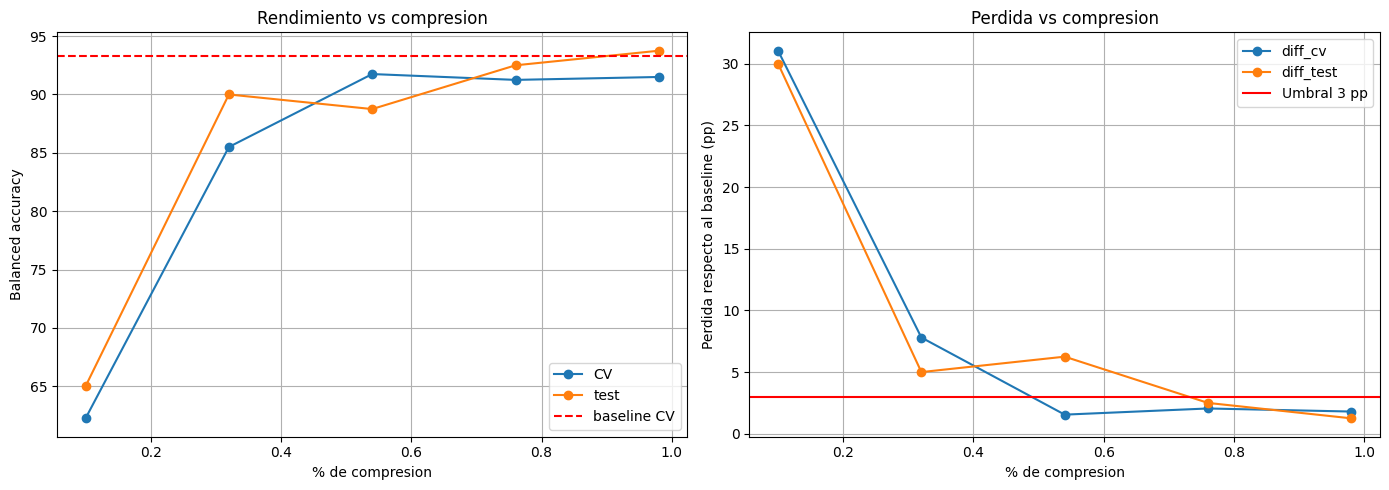

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_resultados_3["compresion_%"], df_resultados_3["eval_cv"], "o-", label="CV")
axes[0].plot(df_resultados_3["compresion_%"], df_resultados_3["eval_test"], "o-", label="test")
axes[0].axhline(y=baseline_cv * 100, color="r", linestyle="--", label="baseline CV")
axes[0].set_xlabel("% de compresion")
axes[0].set_ylabel("Balanced accuracy")
axes[0].set_title("Rendimiento vs compresion")
axes[0].legend()
axes[0].grid()

for linea in ["diff_cv", "diff_test"]:
    axes[1].plot(df_resultados_3["compresion_%"], df_resultados_3[linea], "o-", label=linea)
axes[1].axhline(y=3, color="r", linestyle="-", label="Umbral 3 pp")
axes[1].set_xlabel("% de compresion")
axes[1].set_ylabel("Perdida respecto al baseline (pp)")
axes[1].set_title("Perdida vs compresion")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [23]:
# 4. No podemos perder mas de 3 pp respecto al baseline (ni en CV ni en test)
cumple_3 = (df_resultados_3["diff_cv"] <= 3) & (df_resultados_3["diff_test"] <= 3)
candidatos_3 = df_resultados_3[cumple_3]
display(candidatos_3)

elegido_3 = candidatos_3.loc[candidatos_3["num_pc"].idxmin()]
num_pc_servidor = int(elegido_3["num_pc"])

print(f"\nELEGIDO: {num_pc_servidor} PCs -> compresion al {elegido_3['compresion_%']}% del tamaño original")
print(f"Perdida: {elegido_3['diff_cv']} pp en CV y {elegido_3['diff_test']} pp en test")

,num_pc,compresion_%,eval_cv,baseline_cv,diff_cv,eval_test,baseline_test,diff_test
3,31,0.76,91.25,93.3,2.05,92.50,95.0,2.50
4,40,0.98,91.50,93.3,1.80,93.75,95.0,1.25



ELEGIDO: 31 PCs -> compresion al 0.76% del tamaño original
Perdida: 2.05 pp en CV y 2.5 pp en test


**Conclusion Parte #3:** con **31 PCs** (compresion al **0.76%**, o sea unas 130 veces menos datos) el
servidor central clasifica perdiendo **2.05 pp en CV y 2.5 pp en test** -> dentro del limite de 3 pp.

Tambien cumple 40 PCs (1.8 / 1.25 pp), y de hecho pierde menos, pero **comprime menos** (0.98%). Como el
enunciado nos pide priorizar la compresion (el ancho de banda es minimo), nos quedamos con **31 PCs**.

**Recomendacion final al Caesar Palace:**

| Escenario | PCs | Compresion | Perdida (CV / test) |
|---|---|---|---|
| Modelo **en la microcamara** (clasifica sin descomprimir) | 55 | 1.34% | 1.8 / 0.0 pp |
| Modelo **en el servidor** (descomprime y clasifica) | 31 | 0.76% | 2.05 / 2.5 pp |

* La opcion del **servidor central comprime casi el doble** (0.76% frente a 1.34%), que es justo lo que
  necesitan por el ancho de banda limitado. Ademas la microcamara no gasta CPU en clasificar: solo comprime,
  que es lo unico que sabe hacer rapido.
* **Recomendacion: la opcion del servidor central con 31 PCs.** Es la mas flexible: si algun dia quisieran
  clasificar en la propia camara, con esas mismas componentes (o subiendo a 55) podrian hacerlo sin cambiar
  el compresor de las camaras.
* **Aviso importante:** hay un suelo y no conviene acercarse. Con **22 PCs** el CV parece bueno (solo 1.55 pp)
  pero **en test se cae a 6.25 pp** -> no cumple. Con **13 PCs** perdemos 7.8 pp y con **4 PCs** el modelo se
  hunde (30 pp). Comprimir tiene un limite: por debajo de ~31 PCs la cara pierde la informacion que
  identifica a la persona.
* Fijate en el caso de 22 PCs: es un buen recordatorio de por que miramos **CV y test a la vez**. Si solo
  hubieramos mirado la validacion cruzada, habriamos elegido 22 PCs y en produccion nos habriamos comido
  una perdida del doble de lo permitido.

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

#### EXTRA 1: scatter de las 2 primeras componentes principales, coloreando por persona

In [24]:
# Nos quedamos con las 2 primeras PCs del X_train_pca de la Parte #2
df_extra = pd.DataFrame(X_train_pca[:, :2], columns=["PC_1", "PC_2"])
df_extra["target"] = y_train.values   # .values -> si no, intenta alinear por indice y salen nulos

print("Varianza explicada acumulada por las 2 primeras PCs:",
      round(pca.explained_variance_ratio_[:2].cumsum()[-1] * 100, 2), "%")
df_extra.head()

Varianza explicada acumulada por las 2 primeras PCs: 38.27 %


,PC_1,PC_2,target
0,0.526417,2.222127,13
1,4.355061,2.870462,5
2,4.598106,-0.380969,3
3,-0.847233,-0.746174,12
4,3.364861,3.805031,10


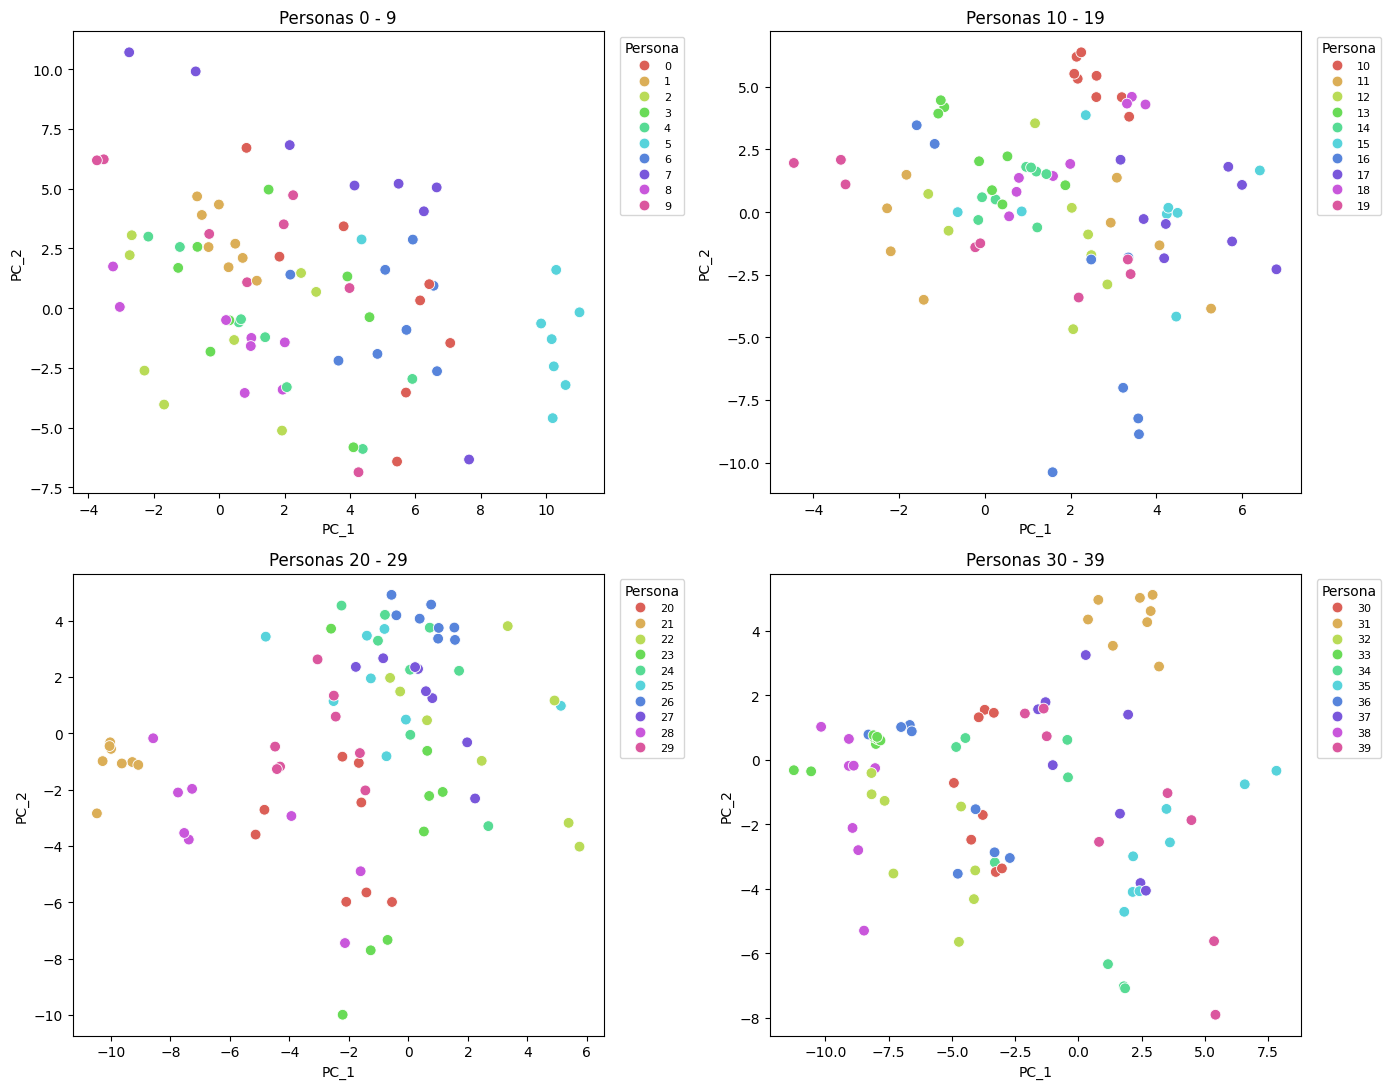

In [25]:
# 40 clases son demasiadas para un solo grafico -> las repartimos en 4 graficos de 10
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for i, ax in enumerate(axes.flatten()):
    desde, hasta = i * 10, (i + 1) * 10
    subset = df_extra[df_extra["target"].isin(range(desde, hasta))]
    # OJO con la paleta: con "viridis" no se distinguen las 10 clases, usamos "hls"
    sns.scatterplot(data=subset, x="PC_1", y="PC_2", hue="target",
                    palette=sns.color_palette("hls", 10), ax=ax, s=60)
    ax.set_title(f"Personas {desde} - {hasta - 1}")
    ax.legend(title="Persona", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

*Con las 2 primeras componentes solo explicamos un **38%** de la varianza, y se nota: **no se ven clusters
claros** por persona, los puntos de distintas caras se solapan. Es decir, aqui el truco de "visualizar el
dataset en 2D con PCA" **no funciona** (a diferencia de datasets mas sencillos como `digits` del workout).
Necesitamos decenas de componentes para separar caras, que es justo lo que vimos en las partes #2 y #3.*

#### EXTRA 2: ¿como se ve una cara comprimida y descomprimida?

In [26]:
# Adaptamos la funcion plot_faces de la practica de KMeans para comparar original vs reconstruida
def pinta_caras(faces, n_cols=5, title=""):
    faces = np.asarray(faces).reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))
    for index, face in enumerate(faces):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

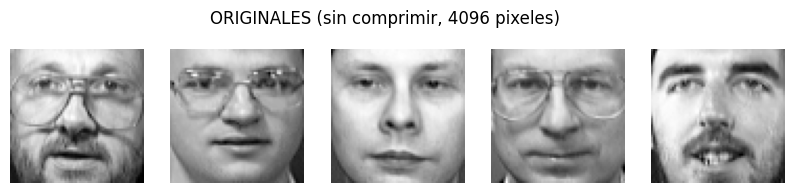

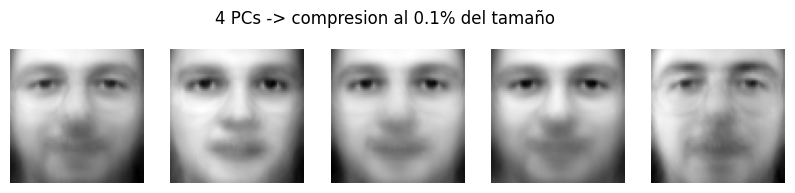

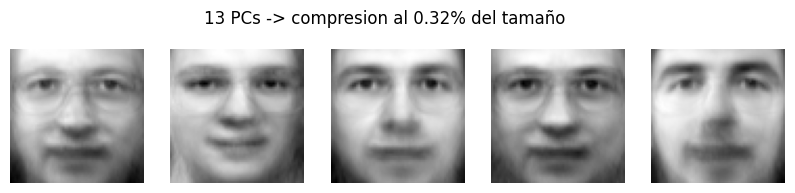

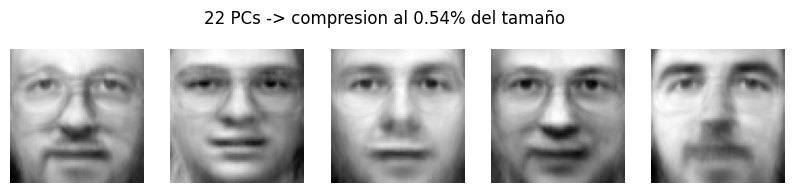

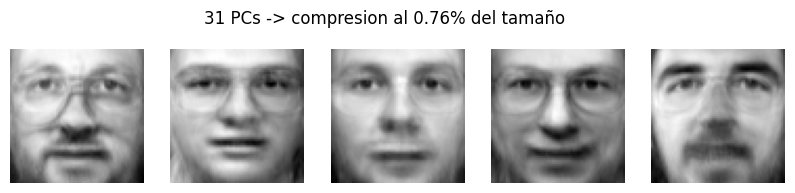

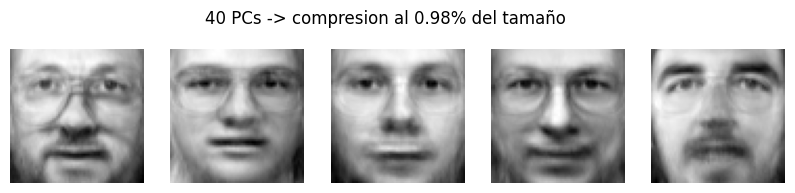

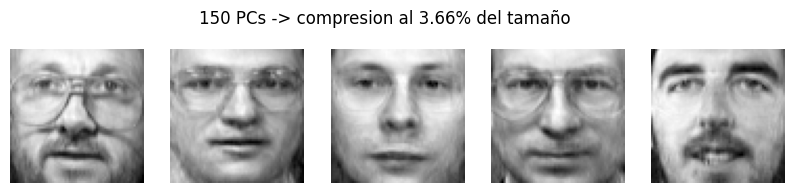

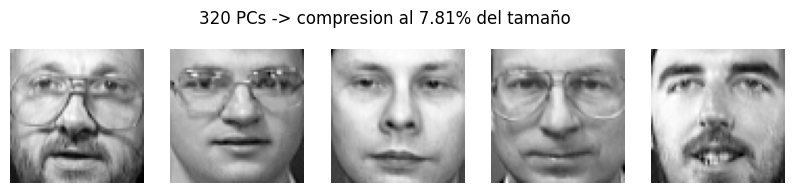

In [27]:
# Añadimos 150 y 320 PCs para que se vea que son las mismas caras cuando casi no comprimimos
pinta_caras(X_train[:5].values, title="ORIGINALES (sin comprimir, 4096 pixeles)")

for num_pc in num_pcs_3 + [150, 320]:
    pca_temp = PCA(num_pc)
    X = pca_temp.fit_transform(X_train)
    X_train_unzipped = pca_temp.inverse_transform(X)
    pinta_caras(X_train_unzipped[:5],
                title=f"{num_pc} PCs -> compresion al {round(num_pc/num_features*100, 2)}% del tamaño")

**Que vemos (y por que encaja con los numeros):**

* Con **4 PCs (0.1%)** las caras son manchas borrosas, casi todas iguales: se ha perdido la identidad de la
  persona. Por eso el modelo se desplomaba a un 61% de balanced accuracy.
* Con **13-22 PCs** ya se intuye quien es cada uno, pero muy suavizado (como un retrato "promedio").
* Con **40 PCs (0.98%)** las caras son perfectamente reconocibles -> y el modelo solo pierde 1.5-2.5 pp.
* Con **150 y 320 PCs** son practicamente identicas a las originales. Confirma que **son las mismas caras**
  y que PCA no las "cambia", solo les quita detalle (la varianza que menos aporta).

**Moraleja:** PCA no borra pixeles al azar, elimina primero el detalle **menos informativo**. Por eso podemos
tirar el 99% del tamaño y seguir reconociendo a la persona.